<a href="https://colab.research.google.com/github/Venni2911/LogicMojo-AI-ML-Sept25-VenniRaj/blob/main/Hyperparameter_Tuning_for_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hyperparameter Tuning for Neural Networks

# Agenda
* Introduction to Hyperparameters
* Hyperparameter Tuning Methods
* Summary

#Introduction to Hyperparameters


- Hyperparameters are configuration settings that are specified before the training process begins and remain constant throughout the training. Unlike model parameters, which are learned from the data during training (such as weights and biases), hyperparameters control the learning process and the structure of the model.

**Examples of Hyperparameters:**

**Learning Rate:**
- Definition: The step size used by the optimization algorithm to update model parameters.
- Impact: A high learning rate can lead to rapid convergence but risks overshooting the optimal solution, while a low learning rate ensures gradual convergence but can be very slow.
- Typical Values: Common values range from 0.0001 to 0.1.

**Batch Size:**
- Definition: The number of training samples used in one forward and backward pass.
- Impact: Larger batch sizes can lead to more stable updates but require more memory, while smaller batch sizes offer noisy updates but require less memory.
- Typical Values: Powers of 2 are common (e.g., 32, 64, 128).

**Number of Epochs:**
- Definition: The number of complete passes through the entire training dataset.
- Impact: More epochs can improve learning but risk overfitting if too many are used.
- Typical Values: Usually between 10 and 1000, depending on the dataset and model complexity.

**Number of Layers:**
- Definition: The depth of the neural network, or how many layers of neurons it has.
- Impact: More layers allow the model to learn more complex patterns but increase computational complexity and risk overfitting.
- Typical Values: Ranges from a few layers for simple models to hundreds in deep learning models like CNNs and RNNs.

**Number of Neurons in Each Layer:**
- Definition: The width of each layer, or how many neurons are present in a single layer.
- Impact: More neurons can capture more features but also increase the risk of overfitting and computational cost.
- Typical Values: Varies widely, typically between 10 and 1000 depending on the problem and dataset.

**Activation Functions:**
- Definition: Functions applied to the output of each neuron to introduce non-linearity.

- Impact: Different activation functions can influence how the model learns and converges.

**Optimization Algorithms:**
- Definition: Algorithms used to minimize the loss function by updating model parameters.
Common Algorithms:
- SGD (Stochastic Gradient Descent): Updates parameters using a single or a few training examples.
- Adam (Adaptive Moment Estimation): Combines the advantages of two other extensions of stochastic gradient descent, specifically AdaGrad and RMSProp.
- RMSProp (Root Mean Square Propagation): Adaptively adjusts the learning rate for each parameter.
- Impact: Different optimizers can converge faster and find better minima.

**Dropout Rates:**
- Definition: The fraction of neurons to drop during training to prevent overfitting.
- Impact: Helps in regularization by preventing neurons from co-adapting too much.
- Typical Values: Ranges from 0.1 to 0.5.

**Weight Initialization Methods:**
- Definition: Strategies for setting the initial values of the weights before training begins.
- Common Methods:
Random Initialization: Initial weights are chosen randomly.
- Xavier/Glorot Initialization: Suitable for tanh and sigmoid activations.
- He Initialization: Suitable for ReLU activation.
- Impact: Proper initialization can lead to faster convergence and better performance.


##Visualizing Hyperparameter Effects

####Learning Curves

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Learning Curve')
    plt.show()

# Example usage after training a Keras model
# plot_learning_curve(history)


####Hyperparameter Heatmaps

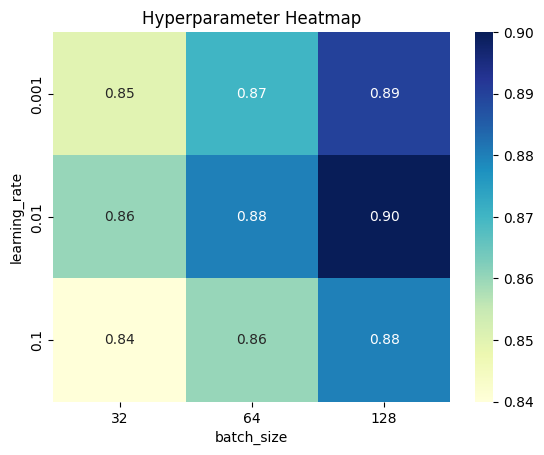

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Sample data: hyperparameters and their corresponding scores
data = {
    'learning_rate': [0.001, 0.001, 0.001, 0.01, 0.01, 0.01, 0.1, 0.1, 0.1],
    'batch_size': [32, 64, 128, 32, 64, 128, 32, 64, 128],
    'score': [0.85, 0.87, 0.89, 0.86, 0.88, 0.90, 0.84, 0.86, 0.88]
}

df = pd.DataFrame(data)
heatmap_data = df.pivot(index='learning_rate', columns='batch_size', values='score')

sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Hyperparameter Heatmap')
plt.show()


#### Scatter Plot

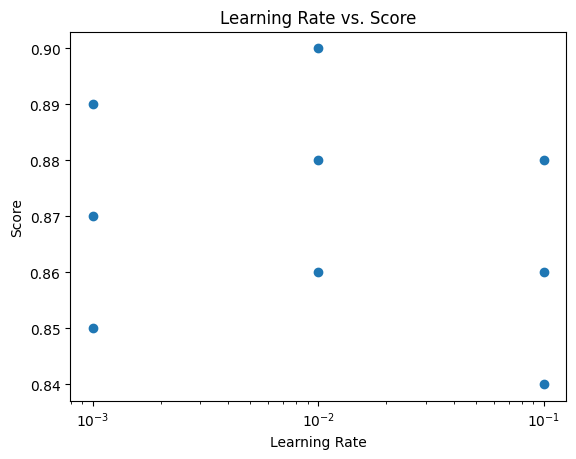

In [ ]:
import matplotlib.pyplot as plt

# Sample data: hyperparameters and their corresponding scores
data = {
    'learning_rate': [0.001, 0.001, 0.001, 0.01, 0.01, 0.01, 0.1, 0.1, 0.1],
    'batch_size': [32, 64, 128, 32, 64, 128, 32, 64, 128],
    'score': [0.85, 0.87, 0.89, 0.86, 0.88, 0.90, 0.84, 0.86, 0.88]
}

df = pd.DataFrame(data)

# Scatter plot of learning rate vs. score
plt.scatter(df['learning_rate'], df['score'])
plt.xlabel('Learning Rate')
plt.ylabel('Score')
plt.title('Learning Rate vs. Score')
plt.xscale('log')  # Optional: Use logarithmic scale for better visualization
plt.show()


# Hyperparameter Tuning Methods


####**1. Grid Search**
**Description:**
- Grid search is a systematic, exhaustive search over a specified grid of hyperparameter values. It evaluates all possible combinations of the hyperparameter values to find the best set.

**Pros:**
- Simple to implement and understand.
Guarantees finding the best combination within the provided grid.

**Cons:**
- Computationally expensive, especially with large parameter spaces.
- The search space grows exponentially with the number of hyperparameters.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Load dataset (replace with your dataset)
data = load_iris()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1]
}

# Initialize the MLPClassifier
mlp = MLPClassifier(max_iter=1000)

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(mlp, param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found by GridSearchCV
print("Best parameters found: ", grid_search.best_params_)

# Predict on the test set
y_pred = grid_search.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:  {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



####**2. Random Search**
**Description:**
- Random search randomly selects hyperparameters from the specified ranges and evaluates them. Unlike grid search, it does not evaluate all possible combinations but selects random combinations instead.

**Pros:**
- More efficient than grid search.
- Can potentially find better models since it explores more diverse combinations.

**Cons:**
- Still computationally intensive.
- May require many iterations to find optimal values.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (150,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1]
}

mlp = MLPClassifier(max_iter=1000)
random_search = RandomizedSearchCV(mlp, param_dist, n_iter=50, cv=5, n_jobs=-1)
random_search.fit(X_train, y_train)

print("Best parameters found: ", random_search.best_params_)


Best parameters found:  {'learning_rate_init': 0.001, 'hidden_layer_sizes': (100,), 'alpha': 0.001, 'activation': 'tanh'}


####**3. Bayesian Optimization**
**Description:**
- Bayesian optimization builds a probabilistic model of the objective function and uses it to select the most promising hyperparameters to evaluate next. It iteratively updates the model based on past evaluations to predict which hyperparameter combinations will perform best.

**Pros:**
- Efficient in terms of the number of evaluations.
- Can handle expensive function evaluations well.

**Cons:**
- More complex to implement.
- Requires more computational resources per evaluation.

**Example Libraries:**
- Scikit-Optimize (skopt)
- Hyperopt
- Optuna


In [ ]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score

def objective(space):
    mlp = MLPClassifier(hidden_layer_sizes=space['hidden_layer_sizes'],
                        activation=space['activation'],
                        alpha=space['alpha'],
                        learning_rate_init=space['learning_rate_init'],
                        max_iter=1000)
    scores = cross_val_score(mlp, X_train, y_train, cv=5)
    return {'loss': -scores.mean(), 'status': STATUS_OK}

space = {
    'hidden_layer_sizes': hp.choice('hidden_layer_sizes', [(50,), (100,), (150,)]),
    'activation': hp.choice('activation', ['relu', 'tanh']),
    'alpha': hp.loguniform('alpha', -4, 0),
    'learning_rate_init': hp.loguniform('learning_rate_init', -4, 0)
}

trials = Trials()
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=50,
            trials=trials)

print("Best parameters found: ", best)


100%|██████████| 50/50 [00:29<00:00,  1.70trial/s, best loss: -0.9619047619047618]
Best parameters found:  {'activation': 0, 'alpha': 0.13528492750737908, 'hidden_layer_sizes': 1, 'learning_rate_init': 0.0761367141344856}


####**4. Hyperband**
**Description:**
- Hyperband combines random search and early stopping to allocate resources efficiently. It allocates resources to a large number of configurations and gradually increases resources for promising configurations while stopping poorly performing ones early.

**Pros:**
- Efficient resource allocation.
- Effective for large search spaces.

**Cons:**
- May require careful tuning of its own parameters, like the maximum resources per configuration.

**Example Libraries:**
- Scikit-Optimize (skopt)
- Keras Tuner
- Optuna

In [ ]:
import keras_tuner as kt
from tensorflow import keras

def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28, 28)))
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(keras.layers.Dense(units=hp.Int('units_' + str(i),
                        min_value=32,
                        max_value=512,
                        step=32),
                        activation='relu'))
    model.add(keras.layers.Dense(10, activation='softmax'))
    model.compile(optimizer=keras.optimizers.Adam(
                    hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
    return model

tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=10,
                     factor=3,
                     directory='my_dir',
                     project_name='intro_to_kt')

tuner.search(X_train, y_train, epochs=50, validation_data=(X_val, y_val))

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hps)


Trial 28 Complete [00h 01m 31s]
val_accuracy: 0.9764999747276306

Best val_accuracy So Far: 0.9820833206176758
Total elapsed time: 00h 23m 34s

Search: Running Trial #29

Value             |Best Value So Far |Hyperparameter
2                 |1                 |num_layers
448               |320               |units_0
0.0001            |0.001             |learning_rate
32                |256               |units_1
160               |384               |units_2
10                |10                |tuner/epochs
0                 |4                 |tuner/initial_epoch
0                 |2                 |tuner/bracket
0                 |2                 |tuner/round

Epoch 1/10
1500/1500 [==============================] - 14s 9ms/step - loss: 0.5298 - accuracy: 0.8564 - val_loss: 0.2611 - val_accuracy: 0.9288
Epoch 2/10
1500/1500 [==============================] - 13s 9ms/step - loss: 0.2205 - accuracy: 0.9376 - val_loss: 0.1942 - val_accuracy: 0.9470
Epoch 3/10
1500/1500 [=============

#**Summary**
- Hyperparameter tuning is a critical step in optimizing the performance of neural networks. It involves selecting the best combination of hyperparameters, such as learning rate, batch size, and network architecture, to maximize the model's accuracy and efficiency.

**Several methods can be used for hyperparameter tuning:**
- **Grid Search:** This method systematically searches through a predefined set of hyperparameter values. It evaluates the model's performance for each combination of hyperparameters and selects the one with the best performance.

- **Random Search:** Unlike grid search, random search selects hyperparameters randomly from predefined ranges. While this approach may not exhaustively search the entire hyperparameter space, it can be more efficient in finding good hyperparameter combinations, especially for high-dimensional search spaces.

- **Bayesian Optimization:** Bayesian optimization uses probabilistic models to model the objective function (e.g., validation accuracy) and iteratively explores the hyperparameter space to find the optimal combination. It balances exploration and exploitation to efficiently find the best hyperparameters.

**Once hyperparameter tuning is complete, it's essential to visualize the training progress and analyze the importance of hyperparameters:**

- Visualizing Training Progress: Plotting metrics like training loss, validation loss, training accuracy, and validation accuracy over epochs helps monitor the model's performance during training. It allows you to identify issues like overfitting or underfitting and assess convergence.

- Analyzing Hyperparameter Importance: Techniques like feature importance analysis or sensitivity analysis can help understand the impact of different hyperparameters on the model's performance. This understanding can guide future hyperparameter tuning efforts and provide insights into the model's behavior.

